In [2]:
!pip install --upgrade pandas numpy scikit-learn

   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   --------------------------- ------------ 8.7/12.7 MB 42.6 MB/s eta 0:00:01
   ---------------------------------------- 12.7/12.7 MB 40.2 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 45.4 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ----------- ---------------------------- 10.5/37.4 MB 51.0 MB/s eta 0:00:01
   ------------------ --------------------- 17.3/37.4 MB 40.9 MB/s eta 0:00:01
   --------------------------- ------------ 25.4/37.4 MB 40.2 MB/s eta 0:00:01
   ---------------------------------------  36.4/37.4 MB 43.0 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 39.6 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.5.2

   ----- ---------------------------------- 1/7 [numpy]
    Uninstalling numpy-2.5.2:
   ----

  You can safely remove it manually.
  You can safely remove it manually.


=== K-Means 군집화 결과 ===
                       유저수  최소친구수  최대친구수  평균호기심지수    총소모포인트  평균소모포인트
Tier                                                                
1. Low-Tier (고립)     11837      1    468     0.46   2887010   243.90
2. Mid-Tier (핵심 타겟)   2651     11    340     3.67  10988200  4144.93
3. High-Tier (인싸)      937     16    304     6.00   7255980  7743.84


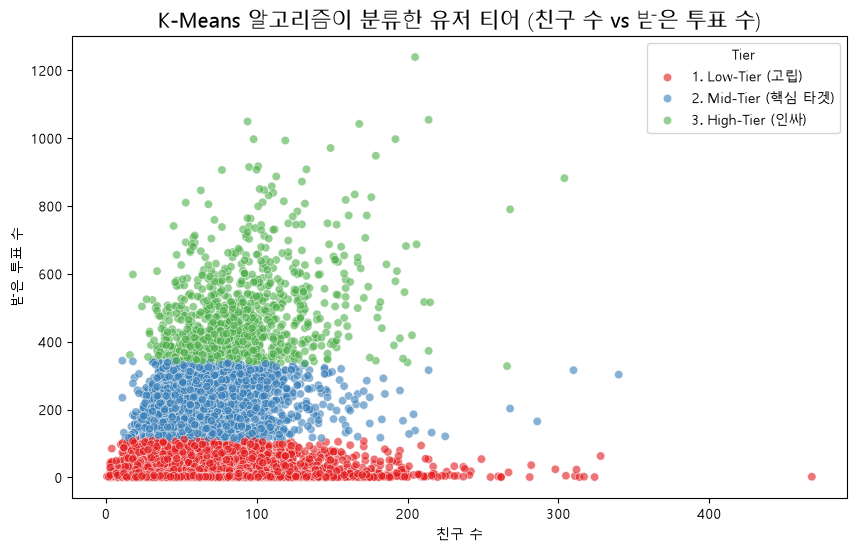

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 지정된 경로의 요약 데이터 로드
file_path = r"C:\Users\wjdtm\OneDrive\바탕 화면\CODEIT DA\Codeit DA Part.4 (2026.08.03 ~ 2026.10.02)\데이터 분석 고급 프로젝트\summary_data.csv"
df = pd.read_csv(file_path, encoding='utf-8')

# 호기심 지수 계산
df['curiosity_index'] = df['received_votes'] / df['friend_count']

# 2. K-Means 클러스터링 학습 (변수: 친구 수, 받은 투표 수)
X = df[['friend_count', 'received_votes']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X)

# 3. 그룹 이름 매핑 (평균 친구 수 기준 정렬)
cluster_centers = df.groupby('cluster_label')['friend_count'].mean().sort_values()
tier_mapping = {
    cluster_centers.index[0]: '1. Low-Tier (고립)',
    cluster_centers.index[1]: '2. Mid-Tier (핵심 타겟)',
    cluster_centers.index[2]: '3. High-Tier (인싸)'
}
df['Tier'] = df['cluster_label'].map(tier_mapping)

# 4. 결과 요약 (K-Means가 찾은 구간 및 과금 성과 확인)
print("=== K-Means 군집화 결과 ===")
summary = df.groupby('Tier').agg(
    유저수=('user_id', 'count'),
    최소친구수=('friend_count', 'min'), # 컴퓨터가 나눈 경계선(시작)
    최대친구수=('friend_count', 'max'), # 컴퓨터가 나눈 경계선(끝)
    평균호기심지수=('curiosity_index', 'mean'),
    총소모포인트=('total_spent', 'sum'), # 실제로 포인트(돈)를 얼마나 썼나?
    평균소모포인트=('total_spent', 'mean')
).round(2)
print(summary)

# 5. 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(x='friend_count', y='received_votes', hue='Tier', data=df, palette='Set1', alpha=0.6)
plt.title('K-Means 알고리즘이 분류한 유저 티어 (친구 수 vs 받은 투표 수)', fontsize=15)
plt.xlabel('친구 수')
plt.ylabel('받은 투표 수')
plt.show()